In [1]:
# Cell 1: Imports
import os
import glob
import tempfile
from pathlib import Path
import numpy as np
import SimpleITK as sitk
import torch
import torch.nn as nn
import random
from monai.transforms import (
    Compose, LoadImageD, AddChannelD, EnsureTyped, SpacingD, OrientationD, ScaleIntensityRangeD,
    RandSpatialCropD, RandFlipD, RandRotate90D, EnsureType, RandGaussianNoiseD
)
from monai.data import Dataset, DataLoader, CacheDataset
from monai.networks.nets import UNet
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.visualize import matshow3d
import matplotlib.pyplot as plt
from tqdm import tqdm


In [2]:
# Cell 2: Configuration & helper functions
DATA_ROOT = "../data"   # change to where your images/masks folders are
IM_DIR = os.path.join(DATA_ROOT, "images")
MASK_DIR = os.path.join(DATA_ROOT, "masks")
OUTPUT_DIR = "./output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Desired spacing used in paper for training IIS baseline
TARGET_SPACING = (2.0, 0.6, 0.6)  # (z, y, x) mm

def load_mha(path):
    itk = sitk.ReadImage(str(path))
    arr = sitk.GetArrayFromImage(itk)  # shape: (z,y,x)
    spacing = itk.GetSpacing()        # (x,y,z) in SimpleITK, careful
    direction = itk.GetDirection()
    origin = itk.GetOrigin()
    return arr, spacing, origin, direction

def write_mha(arr, reference_itk, out_path):
    # arr: numpy (z,y,x)
    out = sitk.GetImageFromArray(arr.astype(np.float32))
    out.SetSpacing(reference_itk.GetSpacing())
    out.SetOrigin(reference_itk.GetOrigin())
    out.SetDirection(reference_itk.GetDirection())
    sitk.WriteImage(out, str(out_path))

def resample_image(itk_image, target_spacing=TARGET_SPACING, is_label=False):
    # itk_image: SimpleITK Image
    # target_spacing: (z, y, x) mm
    # note: SimpleITK uses spacing (x,y,z)
    orig_spacing = itk_image.GetSpacing()  # (x,y,z)
    orig_size = itk_image.GetSize()        # (x,y,z)
    # Build new spacing in SimpleITK order
    new_spacing = (target_spacing[2], target_spacing[1], target_spacing[0])
    new_size = [
        int(np.round(orig_size[i] * (orig_spacing[i] / new_spacing[i]))) for i in range(3)
    ]
    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(new_spacing)
    resampler.SetSize(new_size)
    resampler.SetOutputDirection(itk_image.GetDirection())
    resampler.SetOutputOrigin(itk_image.GetOrigin())
    if is_label:
        resampler.SetInterpolator(sitk.sitkNearestNeighbor)
    else:
        resampler.SetInterpolator(sitk.sitkBSpline)
    res = resampler.Execute(itk_image)
    return res

def sitk_read_and_resample(path, target_spacing=TARGET_SPACING, is_label=False):
    itk = sitk.ReadImage(str(path))
    resampled = resample_image(itk, target_spacing=target_spacing, is_label=is_label)
    arr = sitk.GetArrayFromImage(resampled).astype(np.float32)  # (z,y,x)
    return arr, resampled  # return arr and itk image object for metadata


In [3]:
# Cell 3: Build dataset list
# Expect identical filenames in images/ and masks/ (mha format)
image_paths = sorted(glob.glob(os.path.join(IM_DIR, "*.mha")))
mask_paths = [os.path.join(MASK_DIR, os.path.basename(p)) for p in image_paths]
# keep only pairs where mask exists
pairs = [(i,m) for i,m in zip(image_paths, mask_paths) if os.path.exists(m)]
print(f"Found {len(pairs)} image-mask pairs")

# If dataset small, you can split
random.seed(42)
random.shuffle(pairs)
n_total = len(pairs)
n_val = max(1, int(0.15 * n_total))
train_pairs = pairs[n_val:]
val_pairs = pairs[:n_val]
print("Train:", len(train_pairs), "Val:", len(val_pairs))

Found 447 image-mask pairs
Train: 380 Val: 67


In [ ]:
# Cell 4: Preprocess & create in-memory cache for MONAI (resample & save as npz temp files)
# This step can be slow first time; cache results for faster experiments.
tmp_cache_dir = "../spider_cache_updated"
os.makedirs(tmp_cache_dir, exist_ok=True)

def prepare_case(img_path, mask_path, out_base):
    # read and resample
    img_arr, img_itk = sitk_read_and_resample(img_path, target_spacing=TARGET_SPACING, is_label=False)
    mask_arr, _ = sitk_read_and_resample(mask_path, target_spacing=TARGET_SPACING, is_label=True)
    # normalize intensity per-volume: clip and scale (robust)
    p1, p99 = np.percentile(img_arr, (1,99))
    img_arr = np.clip(img_arr, p1, p99)
    img_arr = (img_arr - img_arr.mean()) / (img_arr.std() + 1e-8)
    # ensure shapes align
    assert img_arr.shape == mask_arr.shape, f"Shape mismatch {img_path}"
    np.savez_compressed(out_base + ".npz", image=img_arr.astype(np.float32), mask=mask_arr.astype(np.uint8))

# Prepare training cached npz files
train_list = []
for i, m in train_pairs:
    base = os.path.join(tmp_cache_dir, Path(i).stem + "_train")
    if not os.path.exists(base + ".npz"):
        prepare_case(i, m, base)
        print("preparing: ", base)
    train_list.append({"image": base + ".npz", "mask": base + ".npz"})

val_list = []
for i, m in val_pairs:
    base = os.path.join(tmp_cache_dir, Path(i).stem + "_val")
    if not os.path.exists(base + ".npz"):
        prepare_case(i, m, base)
        print("preparing: ", base)
    val_list.append({"image": base + ".npz", "mask": base + ".npz"})

print("Prepared cached npz for train/val")

preparing:  ./spider_cache_updated\58_t2_train
preparing:  ./spider_cache_updated\200_t1_train
preparing:  ./spider_cache_updated\51_t2_train
preparing:  ./spider_cache_updated\182_t1_train
preparing:  ./spider_cache_updated\152_t2_SPACE_train
preparing:  ./spider_cache_updated\138_t1_train
preparing:  ./spider_cache_updated\221_t1_train
preparing:  ./spider_cache_updated\171_t1_train
preparing:  ./spider_cache_updated\55_t2_SPACE_train
preparing:  ./spider_cache_updated\227_t1_train
preparing:  ./spider_cache_updated\48_t2_train
preparing:  ./spider_cache_updated\52_t2_SPACE_train
preparing:  ./spider_cache_updated\93_t2_train
preparing:  ./spider_cache_updated\250_t1_train
preparing:  ./spider_cache_updated\221_t2_train
preparing:  ./spider_cache_updated\34_t1_train
preparing:  ./spider_cache_updated\220_t1_train
preparing:  ./spider_cache_updated\137_t2_train
preparing:  ./spider_cache_updated\185_t2_train
preparing:  ./spider_cache_updated\252_t2_train
preparing:  ./spider_cache_up

In [4]:
import os
from pathlib import Path

# use local working dir instead of system temp
tmp_cache_dir = "../spider_cache_updated"
os.makedirs(tmp_cache_dir, exist_ok=True)

# get all cached npz files
all_files = list(Path(tmp_cache_dir).glob("*.npz"))
print("Found cached files:", len(all_files))

train_list, val_list = [], []

for f in all_files:
    fname = f.stem  # e.g., "100_train" or "101_val"
    if "_train" in fname:
        train_list.append({"npz": str(f)})
    elif "_val" in fname:
        val_list.append({"npz": str(f)})

print(f"Found {len(train_list)} training cases and {len(val_list)} validation cases.")


Found cached files: 447
Found 380 training cases and 67 validation cases.


In [5]:
valid_train, valid_val = [], []

for item in train_list:
    try:
        np.load(item['npz'])
        valid_train.append(item)
    except:
        print("Corrupt:", item['npz'])

for item in val_list:
    try:
        np.load(item['npz'])
        valid_val.append(item)
    except:
        print("Corrupt:", item['npz'])


In [6]:
# =============================
# Cell 7: Dataset with correct label mapping
# =============================
class NPZDataset(Dataset):
    def __init__(self, items):
        super().__init__(data=items, transform=None)
        self.items = items

    def __len__(self):
        return len(self.items)

    # def __getitem__(self, idx):
    #     d = np.load(self.items[idx]['npz'])
    #     image = d['image'].astype(np.float32)
    #     mask  = d['mask'].astype(np.uint16)

    #     # --- Correct remapping ---
    #     ch_vertebra = ((mask >= 1) & (mask <= 8)).astype(np.uint8)
    #     ch_disc     = ((mask >= 201) & (mask <= 208)).astype(np.uint8)
    #     ch_canal    = (mask == 100).astype(np.uint8)

    #     multi_mask = np.stack([ch_vertebra, ch_disc, ch_canal], axis=0).astype(np.float32)
    #     image = image[np.newaxis,...].astype(np.float32)

    #     return {"image": image, "mask": multi_mask}

    def __getitem__(self, idx):
        d = np.load(self.items[idx]['npz'])

        image = d['image'].astype(np.float32)
        mask  = d['mask'].astype(np.uint16)

        label = np.zeros_like(mask, dtype=np.uint8)

        # ---- Vertebrae (instance IDs 1–8 as example) ----
        vertebra_ids = np.unique(mask[(mask >= 1) & (mask <= 8)])

        for vid in vertebra_ids:
            if vid % 2 == 1:
                label[mask == vid] = 1   # odd
            else:
                label[mask == vid] = 2   # even

        # ---- Discs (201–208) ----
        label[(mask >= 201) & (mask <= 208)] = 3

        # ---- Spinal canal ----
        label[mask == 100] = 4

        # ---- Shape fixes ----
        image = image[np.newaxis, ...]   # (1, Z, Y, X)

        return {
            "image": image.astype(np.float32),
            "mask": label.astype(np.uint8)
        }


def collate_fn(batch):
    images = torch.from_numpy(np.stack([b['image'] for b in batch])).float()
    labels  = torch.from_numpy(np.stack([b['mask'] for b in batch])).float()
    return {"image": images, "mask": labels}

# Now using only 120 images for training
train_loader = DataLoader(NPZDataset(valid_train[:120]), batch_size=1, shuffle=True, collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(NPZDataset(valid_val[:30]),   batch_size=1, shuffle=False, collate_fn=collate_fn, num_workers=0)
test_loader   = DataLoader(NPZDataset(valid_val[30:]),   batch_size=1, shuffle=False, collate_fn=collate_fn, num_workers=0)


In [7]:

# =============================
# Cell 8: Model & training setup
# =============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

num_classes = 5
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=num_classes,
    channels=(16,32,64,128),
    strides=(2,2,2),
    num_res_units=2,
).to(device)

dice_loss = DiceLoss(sigmoid=True, include_background=False)
bce_loss  = nn.BCEWithLogitsLoss()

def combined_loss(pred, target):
    return 0.7 * dice_loss(pred, target) + 0.3 * bce_loss(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

# AMP for memory efficiency
from torch.amp import autocast, GradScaler
scaler = GradScaler("cuda")

Device: cuda


In [8]:
from monai.losses import DiceCELoss

loss_fn = DiceCELoss(
    include_background=False,
    softmax=True,
    to_onehot_y=True
)

In [9]:
import torch.nn.functional as F

def pad_to_multiple_pair(img, mask, multiple=16):
    d, h, w = img.shape[-3:]
    pad_d = (multiple - d % multiple) % multiple
    pad_h = (multiple - h % multiple) % multiple
    pad_w = (multiple - w % multiple) % multiple
    pad_args = (0, pad_w, 0, pad_h, 0, pad_d)  # (w_left, w_right, h_left, h_right, d_left, d_right)
    img = F.pad(img, pad_args)
    mask = F.pad(mask, pad_args)
    return img, mask

In [ ]:
# =============================
# Cell 9: Training loop
# =============================
n_epochs = 30
best_val_dice = 0.0
ROI_SIZE   = (64, 128, 128)   # patch size, divisible by 16 ## to be changed to larger z height for odd/even strategy (128, 96, 96) or (128, 128, 128)if memory allows
OVERLAP    = 0.25
save_path = os.path.join(OUTPUT_DIR, "best_model2.pth")

for epoch in range(1, n_epochs+1):
    model.train()
    train_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{n_epochs} train"):
        images, masks = batch['image'].to(device), batch['mask'].long().to(device)
        images, masks = pad_to_multiple_pair(images, masks)
        
        optimizer.zero_grad()
        with autocast("cuda"):
            outputs = model(images)
            # loss = combined_loss(outputs, masks)
            masks = masks.unsqueeze(1)   # [B, 1, Z, Y, X]
            loss = loss_fn(outputs, masks)  # labels: (B,Z,Y,X)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss, dices = 0.0, []
    with torch.no_grad():
        for batch in val_loader:
            images, masks = batch['image'].to(device), batch['mask'].long().to(device)
            images, masks = pad_to_multiple_pair(images, masks)
            outputs = model(images)
            # vloss = combined_loss(outputs, masks).item()
            masks = masks.unsqueeze(1)   # [B, 1, Z, Y, X]
            vloss = loss_fn(outputs, masks)  # labels: (B,Z,Y,X)
            val_loss += vloss.item()

            probs = torch.softmax(outputs, dim=1)
            pred  = torch.argmax(probs, dim=1)  # (B,Z,Y,X)

            per_class_d = []
            for cls in range(1, 5):
                inter = ((pred == cls) & (masks == cls)).sum()
                union = (pred == cls).sum() + (masks == cls).sum()
                dice  = (2 * inter / union).item() if union > 0 else 1.0
                per_class_d.append(dice)
            dices.append(per_class_d)

            # probs = torch.sigmoid(outputs)
            # pred = (probs > 0.5).float()

            # per_class_d = []
            # for c in range(num_classes):
            #     inter = (pred[:,c]*masks[:,c]).sum()
            #     union = pred[:,c].sum() + masks[:,c].sum()
            #     per_class_d.append((2*inter/union).item() if union>0 else 1.0)
            # dices.append(per_class_d)

    val_loss /= len(val_loader)
    mean_dice = np.mean(np.array(dices), axis=0)
    print(f"Epoch {epoch} train_loss {train_loss:.4f} val_loss {val_loss:.4f} Dice {mean_dice}")

    scheduler.step(val_loss)
    if mean_dice.mean() > best_val_dice:
        best_val_dice = mean_dice.mean()
        torch.save(model.state_dict(), save_path)
        print("Saved best model.")

print("Training finished. Best val dice:", best_val_dice)


Epoch 1/30 train:   0%|          | 0/120 [00:00<?, ?it/s]

Epoch 1/30 train: 100%|██████████| 120/120 [10:45<00:00,  5.38s/it]


Epoch 1 train_loss 2.0126 val_loss 1.4818 Dice [0.10181828 0.07687529 0.04783888 0.02425956]
Saved best model.


Epoch 2/30 train: 100%|██████████| 120/120 [11:43<00:00,  5.86s/it]


Epoch 2 train_loss 1.2892 val_loss 1.1692 Dice [0.22656509 0.228502   0.03729135 0.05393641]
Saved best model.


...

Epoch 28 train_loss 0.1713 val_loss 0.2944 Dice [0.75456924 0.72267119 0.85955345 0.85574119]


Epoch 29/30 train: 100%|██████████| 120/120 [11:56<00:00,  5.97s/it]


Epoch 29 train_loss 0.1726 val_loss 0.3253 Dice [0.69590459 0.71582356 0.85693325 0.85101461]


Epoch 30/30 train: 100%|██████████| 120/120 [11:40<00:00,  5.84s/it]


Epoch 30 train_loss 0.1864 val_loss 0.3047 Dice [0.73463531 0.72606087 0.85840856 0.84693341]
Training finished. Best val dice: 0.8025136853257815


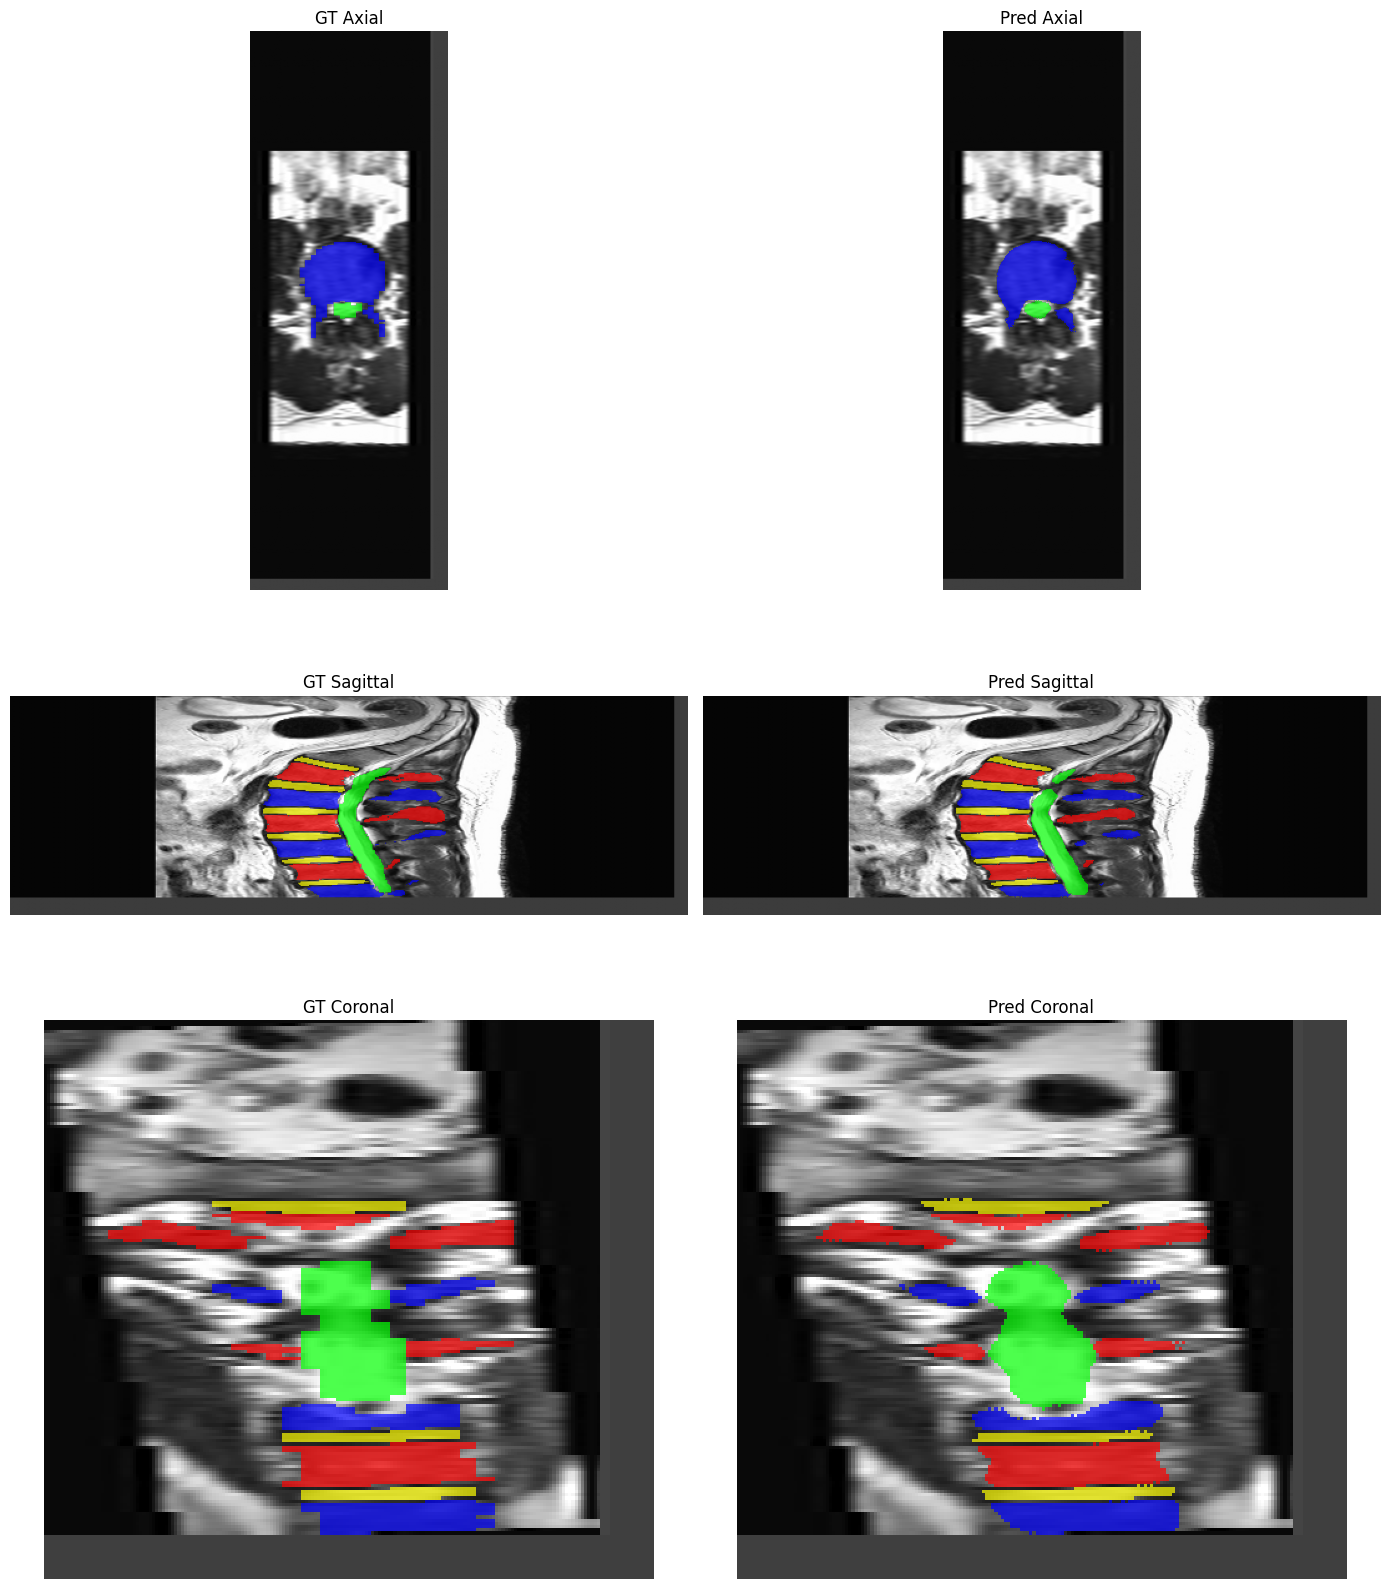

In [10]:
# =============================
# Inference & Visualization
# =============================

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from torch.amp import autocast

# -----------------------------
# CONFIG
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_PATH = os.path.join(OUTPUT_DIR, "best_model7.pth")
CASE_PATH  = "../spider_cache_updated/174_t2_train.npz"

# -----------------------------
# LOAD MODEL (SAFE)
# -----------------------------
model.load_state_dict(
    torch.load(MODEL_PATH, map_location=device, weights_only=True)
)
model.eval()

# -----------------------------
# LOAD CASE
# -----------------------------
d = np.load(CASE_PATH)

image = d["image"].astype(np.float32)[None, None]   # (1,1,Z,Y,X)
mask  = d["mask"].astype(np.int64)[None]            # (1,Z,Y,X)

image_t = torch.from_numpy(image).to(device)
mask_t  = torch.from_numpy(mask).to(device)

# Pad if required
image_t, mask_t = pad_to_multiple_pair(image_t, mask_t)

# -----------------------------
# INFERENCE
# -----------------------------
with torch.no_grad():
    with autocast(device_type="cuda", enabled=(device == "cuda")):
        logits = model(image_t)              # (1,5,Z,Y,X)
        probs  = torch.softmax(logits, dim=1)
        pred   = torch.argmax(probs, dim=1)  # (1,Z,Y,X)

# -----------------------------
# CONVERT TO NUMPY
# -----------------------------
img_np  = image_t[0,0].cpu().numpy()   # (Z,Y,X)
gt_np   = mask_t[0].cpu().numpy()      # (Z,Y,X)
pred_np = pred[0].cpu().numpy()         # (Z,Y,X)

gt_seg = gt_np

# -----------------------------
# SPLIT GT
# -----------------------------
gt_odd   = ((gt_seg >= 1) & (gt_seg <= 9) & ((gt_seg % 2) == 1)).astype(np.uint8)
gt_even  = ((gt_seg >= 1) & (gt_seg <= 9) & ((gt_seg % 2) == 0)).astype(np.uint8)
gt_disc  = ((gt_seg >= 201) & (gt_seg <= 209)).astype(np.uint8)
gt_canal = (gt_seg == 100).astype(np.uint8)

# -----------------------------
# SPLIT PRED
# -----------------------------
pr_odd   = (pred_np == 1).astype(np.uint8)
pr_even  = (pred_np == 2).astype(np.uint8)
pr_disc  = (pred_np == 3).astype(np.uint8)
pr_canal = (pred_np == 4).astype(np.uint8)

# -----------------------------
# SAFE SLICE HELPER
# -----------------------------
def safe_slice(x):
    x = np.squeeze(x)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D slice, got {x.shape}")
    return x

# -----------------------------
# COLOR MAPS
# -----------------------------
odd_cmap   = ListedColormap([[0,0,0,0], [1,0,0,0.7]])   # Red
even_cmap  = ListedColormap([[0,0,0,0], [0,0,1,0.7]])   # Blue
disc_cmap  = ListedColormap([[0,0,0,0], [1,1,0,0.7]])   # Yellow
canal_cmap = ListedColormap([[0,0,0,0], [0,1,0,0.7]])   # Green

# -----------------------------
# OVERLAY FUNCTION
# -----------------------------
def show_overlay(ax, img, odd, even, disc, canal, title):
    ax.imshow(safe_slice(img), cmap="gray")
    ax.imshow(safe_slice(odd),   cmap=odd_cmap)
    ax.imshow(safe_slice(even),  cmap=even_cmap)
    ax.imshow(safe_slice(disc),  cmap=disc_cmap)
    ax.imshow(safe_slice(canal), cmap=canal_cmap)
    ax.set_title(title)
    ax.axis("off")

# -----------------------------
# SLICE INDICES
# -----------------------------
z_mid = img_np.shape[0] // 2
y_mid = img_np.shape[1] // 2
x_mid = img_np.shape[2] // 2

# -----------------------------
# PLOTTING
# -----------------------------
fig, axs = plt.subplots(3, 2, figsize=(14, 16))

# --- Axial ---
show_overlay(
    axs[0,0], img_np[z_mid],
    gt_odd[z_mid], gt_even[z_mid], gt_disc[z_mid], gt_canal[z_mid],
    "GT Axial"
)
show_overlay(
    axs[0,1], img_np[z_mid],
    pr_odd[z_mid], pr_even[z_mid], pr_disc[z_mid], pr_canal[z_mid],
    "Pred Axial"
)

# --- Sagittal ---
show_overlay(
    axs[1,0], img_np[:,:,x_mid],
    gt_odd[:,:,x_mid], gt_even[:,:,x_mid], gt_disc[:,:,x_mid], gt_canal[:,:,x_mid],
    "GT Sagittal"
)
show_overlay(
    axs[1,1], img_np[:,:,x_mid],
    pr_odd[:,:,x_mid], pr_even[:,:,x_mid], pr_disc[:,:,x_mid], pr_canal[:,:,x_mid],
    "Pred Sagittal"
)

# --- Coronal ---
show_overlay(
    axs[2,0], img_np[:,y_mid,:],
    gt_odd[:,y_mid,:], gt_even[:,y_mid,:], gt_disc[:,y_mid,:], gt_canal[:,y_mid,:],
    "GT Coronal"
)
show_overlay(
    axs[2,1], img_np[:,y_mid,:],
    pr_odd[:,y_mid,:], pr_even[:,y_mid,:], pr_disc[:,y_mid,:], pr_canal[:,y_mid,:],
    "Pred Coronal"
)

plt.tight_layout()
plt.show()


Test Results

In [10]:
model_path = os.path.join(OUTPUT_DIR, "best_model7.pth")
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
          (conv): Se

odd-even separate dice score and metrics

In [38]:
test_loss, dices = 0.0, []

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        images, masks = batch['image'].to(device), batch['mask'].to(device)
        images, masks = pad_to_multiple_pair(images, masks)

        # Forward pass
        with autocast("cuda"):
            outputs = model(images)
            masks = masks.unsqueeze(1)
            loss = loss_fn(outputs, masks)
        test_loss += loss.item()

        # Predictions
        probs = torch.softmax(outputs, dim=1)
        pred  = torch.argmax(probs, dim=1)  # (B,Z,Y,X)

        # --- Per-class Dice (same as validation) ---
        per_class_d = []
        for cls in range(1, 5):   # num_classes = 3
            inter = ((pred == cls) & (masks == cls)).sum()
            union = (pred == cls).sum() + (masks == cls).sum()
            dice  = (2 * inter / union).item() if union > 0 else 1.0
            per_class_d.append(dice)

        dices.append(per_class_d)

# Final averages
test_loss /= len(test_loader)
dices = np.array(dices)         
mean_per_class = dices.mean(axis=0)
mean_dice = mean_per_class.mean()

print(f"Test Loss: {test_loss:.4f}")
print("Per-class Dice:", mean_per_class)
print("Mean Dice:", mean_dice)


Testing: 100%|██████████| 37/37 [02:33<00:00,  4.14s/it]

Test Loss: 0.4390
Per-class Dice: [0.59454279 0.53831215 0.83836998 0.85090958]
Mean Dice: 0.7055336245008417


Combined Dice score and metrcis

In [11]:
test_loss = 0.0
dice_vertebrae = []
dice_ivd = []
dice_disc = []

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        images = batch['image'].to(device)
        masks  = batch['mask'].to(device)

        images, masks = pad_to_multiple_pair(images, masks)

        with autocast("cuda"):
            outputs = model(images)
            masks = masks.unsqueeze(1)   # (B,1,Z,Y,X)
            loss = loss_fn(outputs, masks)

        test_loss += loss.item()

        # Predictions
        probs = torch.softmax(outputs, dim=1)
        pred  = torch.argmax(probs, dim=1)  # (B,Z,Y,X)
        gt    = masks.squeeze(1)             # (B,Z,Y,X)

        # -------- SEMANTIC GROUPS --------
        pred_vertebra = (pred == 1) | (pred == 2)
        gt_vertebra   = (gt   == 1) | (gt   == 2)

        pred_ivd = (pred == 3)
        gt_ivd   = (gt   == 3)

        pred_disc = (pred == 4)
        gt_disc   = (gt   == 4)

        def dice_score(pred_fg, gt_fg):
            inter = (pred_fg & gt_fg).sum().float()
            union = pred_fg.sum().float() + gt_fg.sum().float()
            return (2.0 * inter / union).item() if union > 0 else 1.0

        dice_vertebrae.append(dice_score(pred_vertebra, gt_vertebra))
        dice_ivd.append(dice_score(pred_ivd, gt_ivd))
        dice_disc.append(dice_score(pred_disc, gt_disc))

# -------- FINAL METRICS --------
test_loss /= len(test_loader)

print(f"Test Loss: {test_loss:.4f}")
print(f"Vertebra Dice (combined): {np.mean(dice_vertebrae):.4f}")
print(f"IVD Dice: {np.mean(dice_ivd):.4f}")
print(f"Disc Dice: {np.mean(dice_disc):.4f}")
print(f"Mean Semantic Dice: {np.mean([np.mean(dice_vertebrae), np.mean(dice_ivd), np.mean(dice_disc)]):.4f}")


Testing: 100%|██████████| 37/37 [00:31<00:00,  1.16it/s]

Test Loss: 0.4390
Vertebra Dice (combined): 0.8504
IVD Dice: 0.8384
Disc Dice: 0.8509
Mean Semantic Dice: 0.8466


Code for saving combined 3/4 class mask into .nii.gz file

In [12]:
import numpy as np
import torch
import nibabel as nib
from torch.amp import autocast

def save_3class_prediction_as_nifti(
    model,
    image_np,          # (Z,Y,X)
    output_path,
    device,
    classes=3,
    affine=None
):
    model.eval()

    if affine is None:
        affine = np.eye(4)

    # -------------------------------
    # Prepare input
    # -------------------------------
    image = torch.from_numpy(image_np.astype(np.float32))[None, None].to(device)

    dummy_mask = torch.zeros_like(image[:, 0], dtype=torch.long)
    image, _ = pad_to_multiple_pair(image, dummy_mask)

    # -------------------------------
    # Inference
    # -------------------------------
    with torch.no_grad():
        with autocast(device_type="cuda"):
            logits = model(image)
            pred   = torch.argmax(torch.softmax(logits, dim=1), dim=1)

    pred = pred[0].cpu().numpy()

    # -------------------------------
    # REMOVE PADDING
    # -------------------------------
    Z, Y, X = image_np.shape
    pred = pred[:Z, :Y, :X]

    # -------------------------------
    # 🔥 ODD / EVEN → COMBINED REMAP 🔥
    # Original:
    # 0=bg, 1=odd, 2=even, 3=disc, 4=canal
    #
    # Target:
    # 0=bg, 1=vertebra, 2=disc, 3=canal
    # -------------------------------
    combined = np.zeros_like(pred, dtype=np.uint8)

    if classes == 3:

        combined[(pred == 1) | (pred == 2)] = 1   # vertebra
        combined[pred == 3] = 2                   # disc
        combined[pred == 4] = 3                   # canal
    else:
        combined[(pred == 1)] = 1   # odd vertebra
        combined[(pred == 2)] = 2   # even vertebra
        combined[pred == 3] = 3                   # disc
        combined[pred == 4] = 4     # canal

    # -------------------------------
    # Save as NIfTI
    # -------------------------------
    nii = nib.Nifti1Image(combined, affine)
    nii.set_data_dtype(np.uint8)
    nib.save(nii, output_path)

    print(f"Saved {classes}-class combined mask to: {output_path}")


npz = np.load("../spider_cache_updated/174_t2_train.npz")

image_np = npz["image"]
affine = npz["affine"] if "affine" in npz else np.eye(4)

save_3class_prediction_as_nifti(
    model=model,
    image_np=image_np,
    output_path="./predictions/242_pred_4class.nii.gz",
    device=device,
    classes=4,
    affine=affine
)


Saved 4-class combined mask to: ./predictions/242_pred_4class.nii.gz


### Experiments to Solve the merging problem and instance segmentation

Prediction shape: (144, 480, 160)
Detected vertebrae: 77


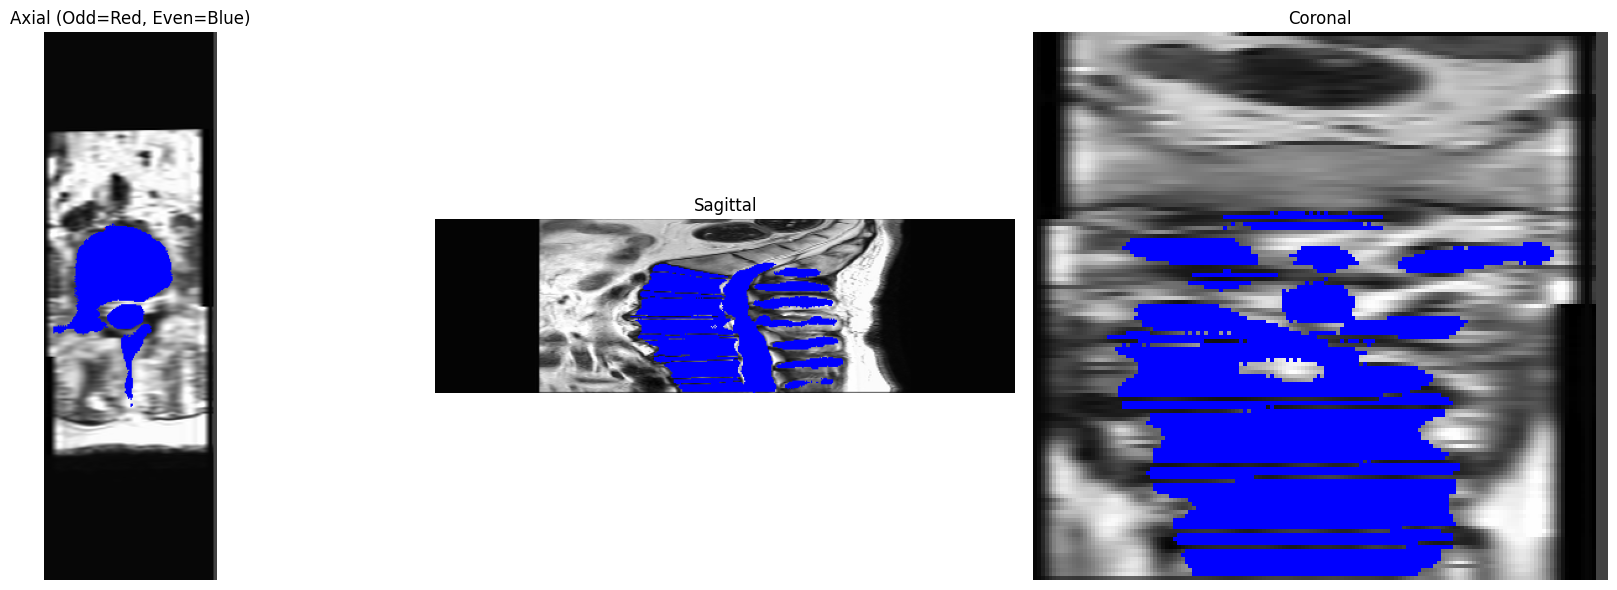

In [45]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import label
from skimage.measure import regionprops

# =========================================================
# 1. MODEL EVALUATION (U-NET)
# =========================================================

# model.eval()

# with torch.no_grad():
#     batch = next(iter(val_loader))  # visualize one batch

#     images = batch["image"].to(device)     # (B,1,Z,Y,X)
#     masks  = batch["mask"].to(device)      # (B,Z,Y,X) or unused

#     outputs = model(images)                # (B,1,Z,Y,X)

#     probs = torch.sigmoid(outputs)
#     pred_mask = (probs > 0.5).cpu().numpy()[0, 0]  # (Z,Y,X)

#     img_np = images.cpu().numpy()[0, 0]            # (Z,Y,X)

# print("Prediction shape:", pred_mask.shape)

# =========================================================
# LOAD SINGLE NPZ IMAGE
# =========================================================

npz_path = "../spider_cache_updated/242_t2_train.npz"   # <-- CHANGE THIS
data = np.load(npz_path)

image = data["image"].astype(np.float32)[None, None]   # (1,1,Z,Y,X)
mask  = data["mask"].astype(np.int64)[None]            # (1,Z,Y,X)

image_t1 = torch.from_numpy(image).to(device)
mask_t1  = torch.from_numpy(mask).to(device)

# Pad if required
image_t, mask_t = pad_to_multiple_pair(image_t1, mask_t1)

# =========================================================
# MODEL INFERENCE
# =========================================================

model.eval()
with torch.no_grad():
    logits = model(image_t)          # (1,1,Z,Y,X)
    probs  = torch.softmax(logits, dim=1)
    pred_mask   = torch.argmax(probs, dim=1)     # (1, Z, Y, X)
    # pred_mask = (probs > 0.5).cpu().numpy()[0, 0]  # (Z,Y,X)

pred_mask = pred_mask[0].cpu().numpy()
print("Prediction shape:", pred_mask.shape)

# =========================================================
# 2. INSTANCE SEGMENTATION (CONNECTED COMPONENTS)
# =========================================================

instance_mask, num_instances = label(pred_mask)
print("Detected vertebrae:", num_instances)

assert num_instances > 0, "No vertebrae detected!"

# =========================================================
# 3. SORT VERTEBRAE CRANIO → CAUDAL (Z AXIS)
# =========================================================

def sort_instances_by_z(instance_mask):
    props = regionprops(instance_mask)
    order = []

    for p in props:
        z_centroid = p.centroid[0]  # Z axis
        order.append((p.label, z_centroid))

    order.sort(key=lambda x: x[1])  # top → bottom
    return [o[0] for o in order]

sorted_ids = sort_instances_by_z(instance_mask)

# =========================================================
# 4. ODD / EVEN MAJORITY ASSIGNMENT (INSTANCE-LEVEL)
# =========================================================

odd_even_mask = np.zeros_like(instance_mask, dtype=np.uint8)

# original shape BEFORE padding
_, _, Z, Y, X = image_t1.shape

instance_mask = instance_mask[:Z, :Y, :X]
odd_even_mask = odd_even_mask[:Z, :Y, :X]

for i, inst_id in enumerate(sorted_ids):
    if (i + 1) % 2 == 1:
        odd_even_mask[instance_mask == inst_id] = 1  # odd
    else:
        odd_even_mask[instance_mask == inst_id] = 2  # even

# =========================================================
# 5. VISUALIZATION HELPERS
# =========================================================

# def colorize_slice(img, inst_slice, oe_slice):
#     """
#     img        : (H,W)
#     inst_slice : (H,W)
#     oe_slice   : (H,W)
#     """
#     img = (img - img.min()) / (img.max() - img.min() + 1e-6)
#     rgb = np.stack([img, img, img], axis=-1)

#     for inst_id in np.unique(inst_slice):
#         if inst_id == 0:
#             continue

#         mask = inst_slice == inst_id
#         cls = np.unique(oe_slice[mask])[0]

#         if cls == 1:        # odd → red
#             rgb[mask] = [1, 0, 0]
#         elif cls == 2:      # even → blue
#             rgb[mask] = [0, 0, 1]

#     return rgb

def colorize_slice(img, inst_slice, oe_slice):
    """
    img        : (H, W) grayscale
    inst_slice : (H, W) instance id (0 = background)
    oe_slice   : (H, W) odd/even class (1=odd, 2=even)
    """
    H, W = img.shape
    rgb = np.stack([img, img, img], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)

    inst_ids = np.unique(inst_slice)
    inst_ids = inst_ids[inst_ids != 0]

    for inst_id in inst_ids:
        mask = inst_slice == inst_id

        cls = int(np.bincount(oe_slice[mask]).argmax())

        if cls == 1:      # odd → red
            rgb[mask] = [1, 0, 0]
        elif cls == 2:    # even → blue
            rgb[mask] = [0, 0, 1]

    return rgb


# =========================================================
# 6. SHOW AXIAL / SAGITTAL / CORONAL
# =========================================================

z_mid = img_np.shape[0] // 2
y_mid = img_np.shape[1] // 2
x_mid = img_np.shape[2] // 2

z_mid = img_np.shape[0] // 2

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].imshow(
    colorize_slice(
        img_np[z_mid],
        instance_mask[z_mid],
        odd_even_mask[z_mid]
    )
)
axs[0].set_title("Axial (Odd=Red, Even=Blue)")
axs[0].axis("off")

axs[1].imshow(
    colorize_slice(
        img_np[:, :, img_np.shape[2]//2],
        instance_mask[:, :, img_np.shape[2]//2],
        odd_even_mask[:, :, img_np.shape[2]//2]
    )
)
axs[1].set_title("Sagittal")
axs[1].axis("off")

axs[2].imshow(
    colorize_slice(
        img_np[:, img_np.shape[1]//2, :],
        instance_mask[:, img_np.shape[1]//2, :],
        odd_even_mask[:, img_np.shape[1]//2, :]
    )
)
axs[2].set_title("Coronal")
axs[2].axis("off")

plt.tight_layout()
plt.show()



In [47]:
import nibabel as nib
import numpy as np

# pred_mask: numpy array of shape (Z, Y, X)
# affine: 4x4 affine matrix from the original image, if you have it

# If your original npz has an affine, you can use it; otherwise use identity
if "affine" in data:
    affine = data["affine"]
else:
    affine = np.eye(4)

# Create NIfTI image
nii_img = nib.Nifti1Image(pred_mask.astype(np.uint8), affine)

# Save to file
output_path = "./predictions/242_t2_pred.nii.gz"
nib.save(nii_img, output_path)

print(f"Saved prediction mask to {output_path}")


Saved prediction mask to ./predictions/242_t2_pred.nii.gz


Detected vertebrae: 64


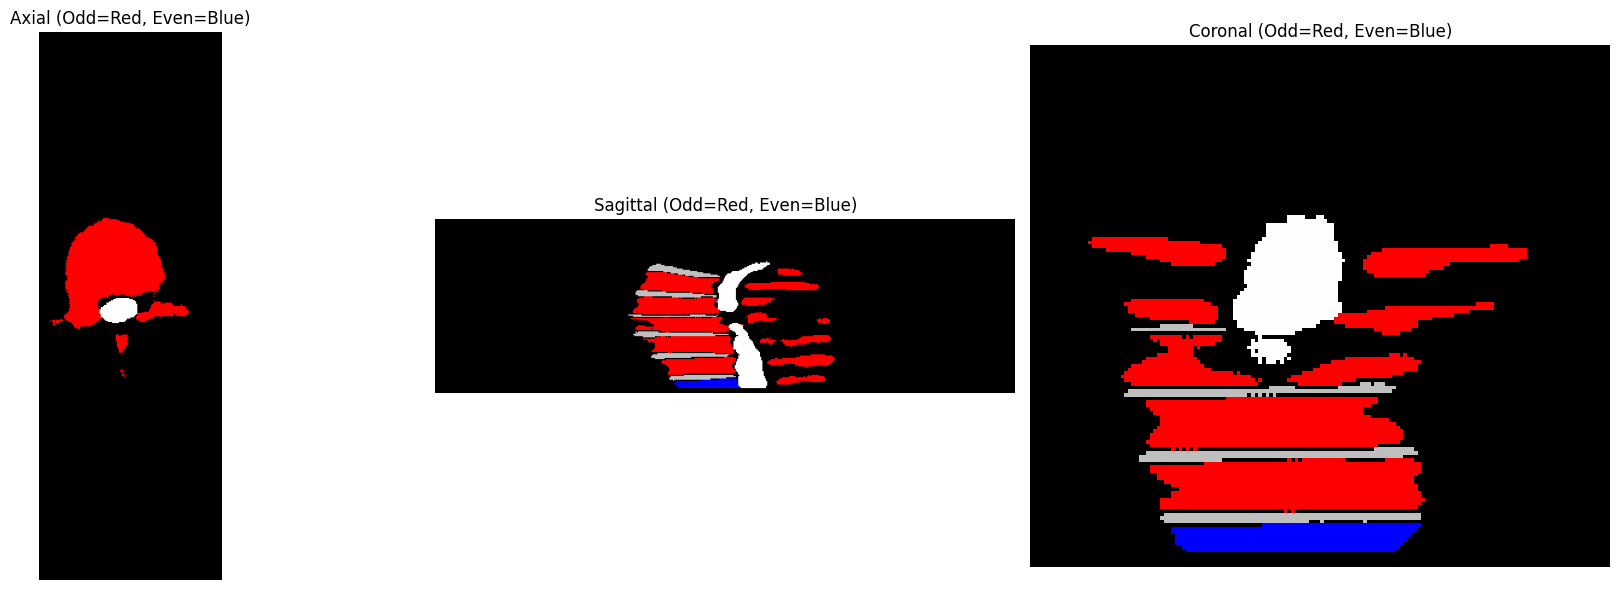

In [2]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import label
from skimage.measure import regionprops

# ------------------------------------------------
# MAJORITY VOTING + INSTANCE LABELING
# ------------------------------------------------
def vertebra_instance_labeling_with_majority(lbl):
    """
    lbl:
      0 = bg
      1 = odd vertebra
      2 = even vertebra
      3 = disc
      4 = canal
    """

    inst = np.zeros_like(lbl, dtype=np.uint16)

    # --- connected components of vertebrae ---
    vertebra_binary = (lbl == 1) | (lbl == 2)
    cc_map, _ = label(vertebra_binary)

    props = regionprops(cc_map)

    blobs = []
    for p in props:
        mask = cc_map == p.label

        # ---- MAJORITY VOTING ----
        values, counts = np.unique(lbl[mask], return_counts=True)
        vote = dict(zip(values, counts))

        odd_votes  = vote.get(1, 0)
        even_votes = vote.get(2, 0)

        majority = 1 if odd_votes >= even_votes else 2

        blobs.append({
            "mask": mask,
            "z": p.centroid[0],
            "class": majority
        })

    # --- sort cranial → caudal ---
    blobs.sort(key=lambda x: x["z"], reverse=True)

    current_id = 1
    odd_even_map = np.zeros_like(lbl, dtype=np.uint8)

    for blob in blobs:
        inst[blob["mask"]] = current_id
        odd_even_map[blob["mask"]] = blob["class"]
        current_id += 1

    # semantic overlays
    inst[lbl == 3] = 200   # disc
    inst[lbl == 4] = 255   # canal

    return inst, odd_even_map


# ------------------------------------------------
# COLORIZE A SINGLE SLICE
# ------------------------------------------------
def colorize_slice(img, inst_slice, oe_slice):
    img = (img - img.min()) / (img.max() - img.min() + 1e-6)
    rgb = np.stack([img]*3, axis=-1)

    for inst_id in np.unique(inst_slice):
        if inst_id == 0 or inst_id >= 200:
            continue

        mask = inst_slice == inst_id
        cls = int(np.bincount(oe_slice[mask]).argmax())

        if cls == 1:       # odd
            rgb[mask] = [1, 0, 0]
        else:              # even
            rgb[mask] = [0, 0, 1]

    return rgb


# ------------------------------------------------
# 3-VIEW VISUALIZATION
# ------------------------------------------------
def visualize_three_views(img, inst, oe):
    z_mid = img.shape[0] // 2
    y_mid = img.shape[1] // 2
    x_mid = img.shape[2] // 2

    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    # AXIAL (Z)
    axs[0].imshow(
        colorize_slice(img[z_mid], inst[z_mid], oe[z_mid])
    )
    axs[0].set_title("Axial (Odd=Red, Even=Blue)")
    axs[0].axis("off")

    # SAGITTAL (X)
    axs[1].imshow(
        colorize_slice(img[:, :, x_mid], inst[:, :, x_mid], oe[:, :, x_mid])
    )
    axs[1].set_title("Sagittal (Odd=Red, Even=Blue)")
    axs[1].axis("off")

    # CORONAL (Y)
    axs[2].imshow(
        colorize_slice(img[:, y_mid, :], inst[:, y_mid, :], oe[:, y_mid, :])
    )
    axs[2].set_title("Coronal (Odd=Red, Even=Blue)")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------
# RUN
# ------------------------------------------------
nii = nib.load("../odd-even-strategy/predictions/242_t2_pred.nii.gz")
lbl = nii.get_fdata().astype(np.uint8)

# Use label volume as grayscale background (or replace with CT/MRI)
img = lbl.astype(np.float32)

instance_mask, odd_even_map = vertebra_instance_labeling_with_majority(lbl)

print("Detected vertebrae:", len(np.unique(instance_mask)) - 3)

visualize_three_views(img, instance_mask, odd_even_map)


Processing...
   -> Found 7 raw blobs. Running fragment merger...
   -> After merging: 2 unique vertebrae.
Final Count: 2 distinct vertebrae.


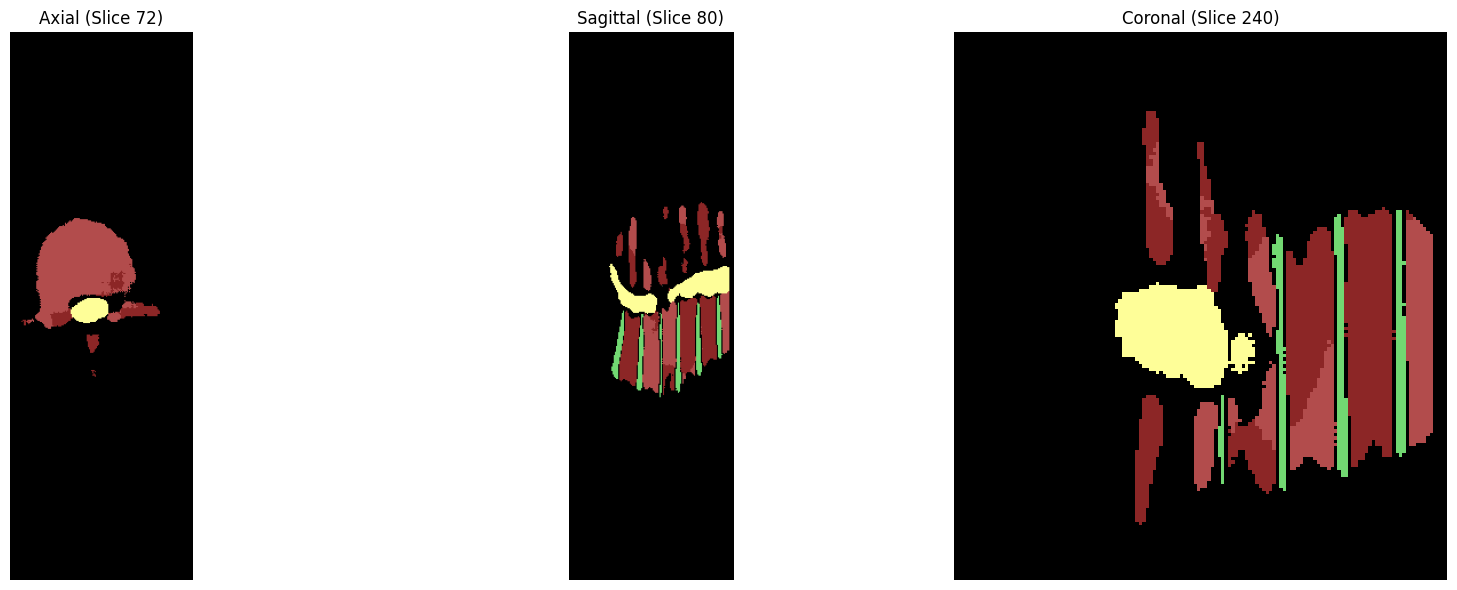

Detected vertebrae: 5


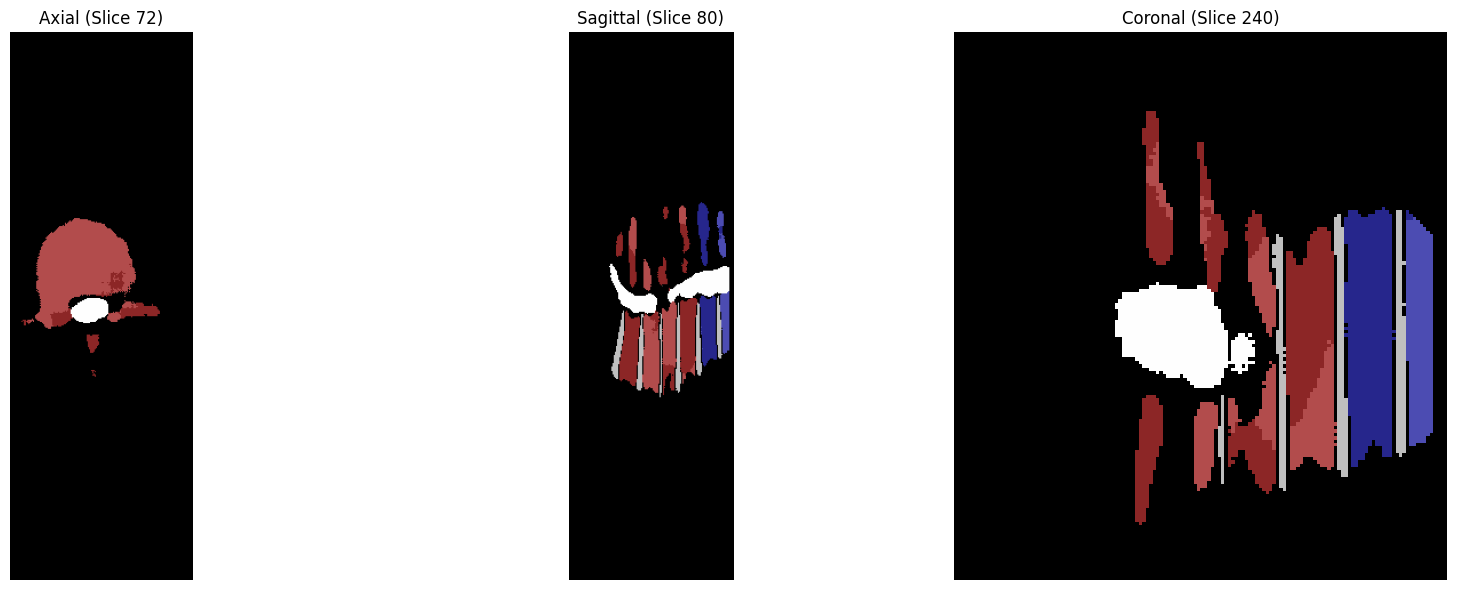

In [4]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import label
from skimage.measure import regionprops

# ------------------------------------------------
# HELPER: Z-AXIS OVERLAP CHECK
# ------------------------------------------------
def calculate_z_overlap(bbox1, bbox2):
    """
    Calculates the vertical (Z-axis) overlap ratio between two bounding boxes.
    Assumes bbox format: (min_z, min_y, min_x, max_z, max_y, max_x)
    Returns: overlap_ratio (0.0 to 1.0) relative to the SMALLER object's height.
    """
    # Unpack Z-coordinates (Axis 0)
    z_min1, z_max1 = bbox1[0], bbox1[3]
    z_min2, z_max2 = bbox2[0], bbox2[3]

    # Calculate height
    h1 = z_max1 - z_min1
    h2 = z_max2 - z_min2

    # Find Intersection
    inter_min = max(z_min1, z_min2)
    inter_max = min(z_max1, z_max2)

    if inter_max <= inter_min:
        return 0.0  # No overlap

    intersection_h = inter_max - inter_min
    
    # We compare overlap relative to the SMALLER object.
    # If the small fragment is 80% inside the big bone, we merge it.
    min_h = min(h1, h2)
    if min_h == 0: return 0.0
    
    return intersection_h / min_h

# ------------------------------------------------
# LOGIC: MERGE FRAGMENTS
# ------------------------------------------------
def merge_fragmented_blobs(blobs_list, overlap_threshold=0.3):
    """
    Iteratively merges smaller blobs into larger blobs if they share Z-space.
    """
    # 1. Sort by Volume (Size) Descending -> We merge small into big
    # Volume is roughy estimated by the sum of the mask pixels
    blobs_list.sort(key=lambda x: np.sum(x['mask']), reverse=True)

    merged_indices = set()
    final_blobs = []

    for i in range(len(blobs_list)):
        if i in merged_indices:
            continue
        
        main_blob = blobs_list[i]
        
        # Look for fragments to eat in the remaining list
        for j in range(i + 1, len(blobs_list)):
            if j in merged_indices:
                continue
            
            candidate_blob = blobs_list[j]
            
            # Check Overlap
            overlap = calculate_z_overlap(main_blob['bbox'], candidate_blob['bbox'])
            
            if overlap > overlap_threshold:
                # MERGE DETECTED!
                # 1. Combine Masks
                main_blob['mask'] = np.logical_or(main_blob['mask'], candidate_blob['mask'])
                
                # 2. Update Bounding Box (Expand to fit both)
                new_z_min = min(main_blob['bbox'][0], candidate_blob['bbox'][0])
                new_z_max = max(main_blob['bbox'][3], candidate_blob['bbox'][3])
                # We only really care about Z for subsequent merges, strictly speaking
                # updating the tuple is a bit verbose, but let's just update the Z parts for correctness
                # or simpler: we don't strictly need to update bbox if we assume main body dominates Z range.
                # But let's be safe:
                orig_bbox = list(main_blob['bbox'])
                cand_bbox = list(candidate_blob['bbox'])
                # Update Min coords
                orig_bbox[0] = min(orig_bbox[0], cand_bbox[0]) # Z
                orig_bbox[1] = min(orig_bbox[1], cand_bbox[1]) # Y
                orig_bbox[2] = min(orig_bbox[2], cand_bbox[2]) # X
                # Update Max coords
                orig_bbox[3] = max(orig_bbox[3], cand_bbox[3]) # Z
                orig_bbox[4] = max(orig_bbox[4], cand_bbox[4]) # Y
                orig_bbox[5] = max(orig_bbox[5], cand_bbox[5]) # X
                main_blob['bbox'] = tuple(orig_bbox)

                # Mark as merged
                merged_indices.add(j)

        final_blobs.append(main_blob)

    return final_blobs

# ------------------------------------------------
# MAIN PIPELINE
# ------------------------------------------------
def vertebra_instance_labeling_pipeline(lbl):
    """
    Full pipeline: 
    1. Extract blobs
    2. Merge fragments (Z-overlap)
    3. Majority Vote Class
    4. Sort & Label
    """
    inst = np.zeros_like(lbl, dtype=np.uint16)
    odd_even_map = np.zeros_like(lbl, dtype=np.uint8)

    # --- 1. CONNECTED COMPONENTS ---
    vertebra_binary = (lbl == 1) | (lbl == 2)
    cc_map, num_features = label(vertebra_binary)
    props = regionprops(cc_map)

    # --- 2. EXTRACT RAW BLOBS ---
    raw_blobs = []
    for p in props:
        # Filter tiny noise (optional)
        if p.area < 50: continue 

        mask = (cc_map == p.label)
        raw_blobs.append({
            "mask": mask,
            "bbox": p.bbox,   # (min_z, min_y, min_x, max_z, max_y, max_x)
            "centroid_z": p.centroid[0]
        })

    print(f"   -> Found {len(raw_blobs)} raw blobs. Running fragment merger...")

    # --- 3. MERGE FRAGMENTS ---
    merged_blobs = merge_fragmented_blobs(raw_blobs, overlap_threshold=0.3)
    print(f"   -> After merging: {len(merged_blobs)} unique vertebrae.")

    # --- 4. ASSIGN CLASSES (MAJORITY VOTE ON MERGED MASKS) ---
    final_blob_data = []
    
    for blob in merged_blobs:
        mask = blob["mask"]
        
        # Recalculate votes on the NEW combined mask
        # We look at the original label map 'lbl' inside this mask
        values, counts = np.unique(lbl[mask], return_counts=True)
        vote = dict(zip(values, counts))
        
        odd_votes  = vote.get(1, 0)
        even_votes = vote.get(2, 0)
        
        majority_class = 1 if odd_votes >= even_votes else 2
        
        # Update centroid (simple average of mask indices)
        # np.argwhere is expensive, so we can approximate or use regionprops again.
        # Faster way: just use the bbox center for sorting
        z_center = (blob['bbox'][0] + blob['bbox'][3]) / 2.0
        
        final_blob_data.append({
            "mask": mask,
            "z": z_center,
            "class": majority_class
        })

    # --- 5. SORT & PAINT ---
    # Sort Cranial -> Caudal (assuming axis 0 is Z)
    final_blob_data.sort(key=lambda x: x["z"], reverse=False) # Check your orientation!
    # Note: Medical images Z usually increases or decreases. 
    # If 0 is top, reverse=False. If 0 is bottom, reverse=True.
    # Adjust 'reverse' based on your specific data orientation!
    
    current_id = 1
    for blob in final_blob_data:
        inst[blob["mask"]] = current_id
        odd_even_map[blob["mask"]] = blob["class"]
        current_id += 1

    # --- 6. ADD SEMANTIC OVERLAYS (DISCS/CANAL) ---
    inst[lbl == 3] = 200   # disc
    inst[lbl == 4] = 255   # canal
    
    # Optional: Fill odd_even_map for discs/canal too if needed for viz
    odd_even_map[lbl == 3] = 3
    odd_even_map[lbl == 4] = 4

    return inst, odd_even_map

# ------------------------------------------------
# VISUALIZATION UTILS
# ------------------------------------------------
def colorize_slice(img, inst_slice, oe_slice):
    # Normalize background image for display
    img_disp = (img - img.min()) / (img.max() - img.min() + 1e-6)
    rgb = np.stack([img_disp]*3, axis=-1)

    # Get unique instances in this slice
    unique_ids = np.unique(inst_slice)

    for inst_id in unique_ids:
        if inst_id == 0: continue
        
        # Masks
        mask = (inst_slice == inst_id)
        
        # Determine Color
        if inst_id == 200:   # Disc
            color = [0, 1, 0] # Green
        elif inst_id == 255: # Canal
            color = [1, 1, 0] # Yellow
        else:
            # It's a bone. Check the Odd/Even map
            # We take the majority class in this slice for this instance
            cls_vals = oe_slice[mask]
            if cls_vals.size == 0: continue
            cls = np.bincount(cls_vals).argmax()
            
            if cls == 1:   color = [1, 0, 0] # Red (Odd)
            elif cls == 2: color = [0, 0, 1] # Blue (Even)
            else:          color = [1, 1, 1] # White (Error?)

        # Apply color overlay with transparency (alpha blending)
        alpha = 0.4
        for c in range(3):
            rgb[mask, c] = (1 - alpha) * rgb[mask, c] + alpha * color[c]

    return rgb

def visualize_three_views(img, inst, oe):
    shape = img.shape
    z_mid, y_mid, x_mid = shape[0]//2, shape[1]//2, shape[2]//2

    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    # AXIAL (Axis 0)
    axs[0].imshow(colorize_slice(img[z_mid], inst[z_mid], oe[z_mid]))
    axs[0].set_title(f"Axial (Slice {z_mid})")
    
    # SAGITTAL (Axis 2) - Flip usually needed for medical view
    axs[1].imshow(np.rot90(colorize_slice(img[:, :, x_mid], inst[:, :, x_mid], oe[:, :, x_mid])))
    axs[1].set_title(f"Sagittal (Slice {x_mid})")

    # CORONAL (Axis 1)
    axs[2].imshow(np.rot90(colorize_slice(img[:, y_mid, :], inst[:, y_mid, :], oe[:, y_mid, :])))
    axs[2].set_title(f"Coronal (Slice {y_mid})")

    for ax in axs: ax.axis("off")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------
# RUNNER
# ------------------------------------------------
if __name__ == "__main__":
    # Load Data
    # NOTE: Ensure your .nii.gz file path is correct
    nii_path = "../odd-even-strategy/predictions/242_t2_pred.nii.gz"
    
    try:
        nii = nib.load(nii_path)
        lbl = nii.get_fdata().astype(np.uint8)
        
        # Use label volume as background (or load corresponding image)
        img = lbl.astype(np.float32)

        print("Processing...")
        instance_mask, odd_even_map = vertebra_instance_labeling_pipeline(lbl)

        # Count bones (excluding disc/canal/bg)
        num_bones = len(np.unique(instance_mask)) - 3 
        # (-3 accounts for: 0=bg, 200=disc, 255=canal. Adjust if specific classes missing)
        
        print(f"Final Count: {max(0, num_bones)} distinct vertebrae.")

        visualize_three_views(img, instance_mask, odd_even_map)

        instance_mask, odd_even_map = vertebra_instance_labeling_with_majority(instance_mask)

        print("Detected vertebrae:", len(np.unique(instance_mask)) - 3)

        visualize_three_views(img, instance_mask, odd_even_map)
        
    except FileNotFoundError:
        print(f"Error: Could not find file at {nii_path}")

Auto-detect spine axis and lebel all the vertebrea at the same z-height into same label

Processing...
   -> Found 4 raw fragments.
   [Auto-Detect] Spine Axis is: Axial (2) (Spread=159.0)
   -> After cleanup: 2 vertebrae remain.
   [Saved] Processed file saved to: ../odd-even-strategy/predictions/242_t2_postprocessed.nii.gz


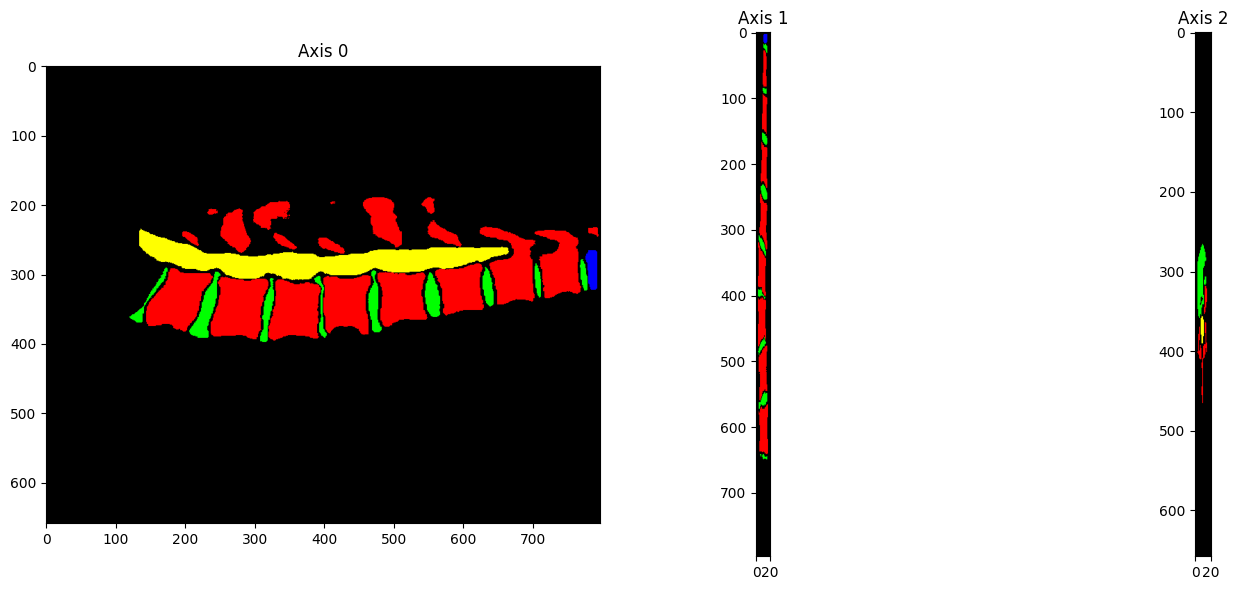

In [14]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import label
from skimage.measure import regionprops
import os

# ==========================================
# CONFIGURATION
# ==========================================
INPUT_PATH  = "../odd-even-strategy/predictions/242_t2_pred.nii.gz"
OUTPUT_PATH = "../odd-even-strategy/predictions/242_t2_postprocessed.nii.gz"
INPUT_PATH = "../nnUNet_raw/Dataset501_SpiderOddEven/labelsTr/Spider_001.nii.gz"

SOLID_COLOR = True  # Set True to hide MRI texture (cartoon look) for debugging

# ------------------------------------------------
# 1. AUTO-DETECT SPINE AXIS
# ------------------------------------------------
def detect_spine_axis(blobs):
    """
    Automatically finds which axis corresponds to the spine's height (Z-axis).
    Logic: The axis with the largest spread of centroids is the spine axis.
    """
    if not blobs: return 0
    
    centroids = np.array([b['centroid'] for b in blobs])
    
    # Calculate standard deviation (spread) for (Axis 0, Axis 1, Axis 2)
    spreads = np.std(centroids, axis=0)
    spine_axis = np.argmax(spreads)
    
    axis_names = {0: "Sagittal (0)", 1: "Coronal (1)", 2: "Axial (2)"}
    print(f"   [Auto-Detect] Spine Axis is: {axis_names.get(spine_axis, str(spine_axis))} (Spread={spreads[spine_axis]:.1f})")
    return spine_axis

# ------------------------------------------------
# 2. OVERLAP LOGIC (AXIS AWARE)
# ------------------------------------------------
def calculate_overlap(bbox1, bbox2, axis):
    """Calculates overlap ONLY along the spine axis."""
    # Bbox format in regionprops is (min_d, min_h, min_w, max_d, max_h, max_w)
    # We need indices [axis] and [axis + 3]
    
    min1, max1 = bbox1[axis], bbox1[axis + 3]
    min2, max2 = bbox2[axis], bbox2[axis + 3]

    inter_min = max(min1, min2)
    inter_max = min(max1, max2)

    if inter_max <= inter_min: return 0.0

    intersection = inter_max - inter_min
    
    # Compare against smaller object height
    h1 = max1 - min1
    h2 = max2 - min2
    min_h = min(h1, h2)
    
    if min_h == 0: return 0.0
    return intersection / min_h

# ------------------------------------------------
# 3. MERGE FRAGMENTS
# ------------------------------------------------
def merge_fragments(blobs, axis):
    """Merges small floating fragments into main bones."""
    # Sort by Volume (Largest first)
    blobs.sort(key=lambda x: np.sum(x['mask']), reverse=True)
    
    merged_indices = set()
    final_blobs = []

    for i in range(len(blobs)):
        if i in merged_indices: continue
        main_blob = blobs[i]
        
        for j in range(i + 1, len(blobs)):
            if j in merged_indices: continue
            cand = blobs[j]
            
            # If overlap > 30% along the spine axis, it's the same bone
            if calculate_overlap(main_blob['bbox'], cand['bbox'], axis) > 0.3:
                # Merge
                main_blob['mask'] = np.logical_or(main_blob['mask'], cand['mask'])
                
                # Update bbox (simplified: just take min/max of union for the spine axis)
                new_bbox = list(main_blob['bbox'])
                cand_bbox = cand['bbox']
                
                # Expand bounding box to include the fragment
                new_bbox[axis] = min(new_bbox[axis], cand_bbox[axis])
                new_bbox[axis+3] = max(new_bbox[axis+3], cand_bbox[axis+3])
                main_blob['bbox'] = tuple(new_bbox)
                
                merged_indices.add(j)
                
        final_blobs.append(main_blob)
    return final_blobs

# ------------------------------------------------
# 4. ZIPPER SORTING
# ------------------------------------------------
def apply_zipper(blobs, axis, raw_lbl):
    """Sorts bones along spine axis and forces 1-2-1-2 pattern."""
    if not blobs: return []

    # Sort by the Min coordinate of the Spine Axis
    blobs.sort(key=lambda x: x['bbox'][axis])
    
    # Determine Starting Class (Odd or Even) from the TOP bone
    top_mask = blobs[0]['mask']
    vals, counts = np.unique(raw_lbl[top_mask], return_counts=True)
    vote = dict(zip(vals, counts))
    
    # If Class 2 has more votes, start with 2. Else 1.
    current_class = 2 if vote.get(2, 0) > vote.get(1, 0) else 1
    
    for blob in blobs:
        blob['forced_class'] = current_class
        current_class = 2 if current_class == 1 else 1 # Toggle
        
    return blobs

# ------------------------------------------------
# MAIN PROCESSING
# ------------------------------------------------
def process_spine(lbl_data):
    # 1. Binarize & Label
    binary = (lbl_data == 1) | (lbl_data == 2)
    cc, _ = label(binary)
    props = regionprops(cc)
    
    # 2. Extract Blobs
    blobs = []
    for p in props:
        if p.area < 50: continue # Filter dust
        blobs.append({
            "mask": (cc == p.label),
            "bbox": p.bbox,
            "centroid": p.centroid
        })
    
    print(f"   -> Found {len(blobs)} raw fragments.")
    
    # 3. Detect Axis
    spine_axis = detect_spine_axis(blobs)
    
    # 4. Merge
    merged_blobs = merge_fragments(blobs, spine_axis)
    print(f"   -> After cleanup: {len(merged_blobs)} vertebrae remain.")
    
    # 5. Zipper
    final_blobs = apply_zipper(merged_blobs, spine_axis, lbl_data)
    
    # 6. Reconstruct Volumes
    # 'inst' = 1, 2, 3... (Unique IDs)
    # 'oe'   = 1, 2       (Classes)
    inst_vol = np.zeros_like(lbl_data, dtype=np.uint16)
    oe_vol   = np.zeros_like(lbl_data, dtype=np.uint8)
    
    for i, blob in enumerate(final_blobs, start=1):
        m = blob['mask']
        c = blob['forced_class']
        inst_vol[m] = i
        oe_vol[m]   = c
        
    # Add Disc (3) and Canal (4)
    inst_vol[lbl_data == 3] = 200
    inst_vol[lbl_data == 4] = 255
    oe_vol[lbl_data == 3]   = 3
    oe_vol[lbl_data == 4]   = 4
    
    return inst_vol, oe_vol

# ------------------------------------------------
# SAVING & VISUALIZATION
# ------------------------------------------------
def save_nifti(data, affine, header, path):
    new_img = nib.Nifti1Image(data, affine, header)
    nib.save(new_img, path)
    print(f"   [Saved] Processed file saved to: {path}")

def visualize(img, inst, oe):
    z, y, x = img.shape
    mid = [z//2, y//2, x//2]
    
    fig, axs = plt.subplots(1, 3, figsize=(15, 6))
    
    def get_rgb(sl_img, sl_inst, sl_oe):
        # Normalize MRI
        sl_img = (sl_img - sl_img.min()) / (sl_img.max() - sl_img.min() + 1e-5)
        rgb = np.stack([sl_img]*3, axis=-1)
        
        ids = np.unique(sl_inst)
        for i in ids:
            if i == 0: continue
            mask = (sl_inst == i)
            
            # Pick Color
            if i == 200:   col = [0, 1, 0] # Green (Disc)
            elif i == 255: col = [1, 1, 0] # Yellow (Canal)
            else:
                # Bone Class
                vals = sl_oe[mask]
                if len(vals) == 0: continue
                c = vals[0] # All pixels in bone are same class now
                if c == 1:   col = [1, 0, 0] # Red
                elif c == 2: col = [0, 0, 1] # Blue
                else:        col = [1, 1, 1]

            # Paint
            if SOLID_COLOR:
                # Opaque color (Cartoon style) - Fixes "Mixed/Light/Bright" confusion
                rgb[mask] = col 
            else:
                # Transparent overlay
                rgb[mask] = rgb[mask]*0.4 + np.array(col)*0.6
                
        return rgb

    axs[0].imshow(get_rgb(img[mid[0]], inst[mid[0]], oe[mid[0]]))
    axs[0].set_title("Axis 0")
    
    axs[1].imshow(np.rot90(get_rgb(img[:, mid[1], :], inst[:, mid[1], :], oe[:, mid[1], :])))
    axs[1].set_title("Axis 1")
    
    axs[2].imshow(np.rot90(get_rgb(img[:, :, mid[2]], inst[:, :, mid[2]], oe[:, :, mid[2]])))
    axs[2].set_title("Axis 2")
    
    plt.tight_layout()
    plt.show()

# ------------------------------------------------
# RUNNER
# ------------------------------------------------
if __name__ == "__main__":
    if not os.path.exists(INPUT_PATH):
        print(f"Error: File not found at {INPUT_PATH}")
    else:
        # Load
        nii = nib.load(INPUT_PATH)
        lbl = nii.get_fdata().astype(np.uint8)
        img = lbl.astype(np.float32) # Use label as bg for now
        
        print("Processing...")
        
        # Pipeline
        final_inst, final_oe = process_spine(lbl)
        
        # Save
        # Note: We save 'final_inst' which has unique IDs (1,2,3...)
        # If you want to save the Red/Blue classes, save 'final_oe'.
        # Here we save the Instance Map (better for downstream tasks).
        save_nifti(final_inst, nii.affine, nii.header, OUTPUT_PATH)
        
        # Visualize
        visualize(img, final_inst, final_oe)

   [1] Closing cracks...
   [2] Eroding connections...
   [3] Found 13 potential cores (filtered from 43).
   [Axis Detect] Spine detected along Axis 2 (Spread=212.3)
   [4] Merging close fragments (Threshold=15)...
      -> Merging fragments at 194.1 and 204.3 (dist=10.3)
      -> Merging fragments at 782.2 and 786.0 (dist=3.7)
       -> Final Count: 11 vertebrae.
   [5] Watershed Expansion...
   [Saved] ../odd-even-strategy/predictions/242_t2_postprocessed.nii.gz


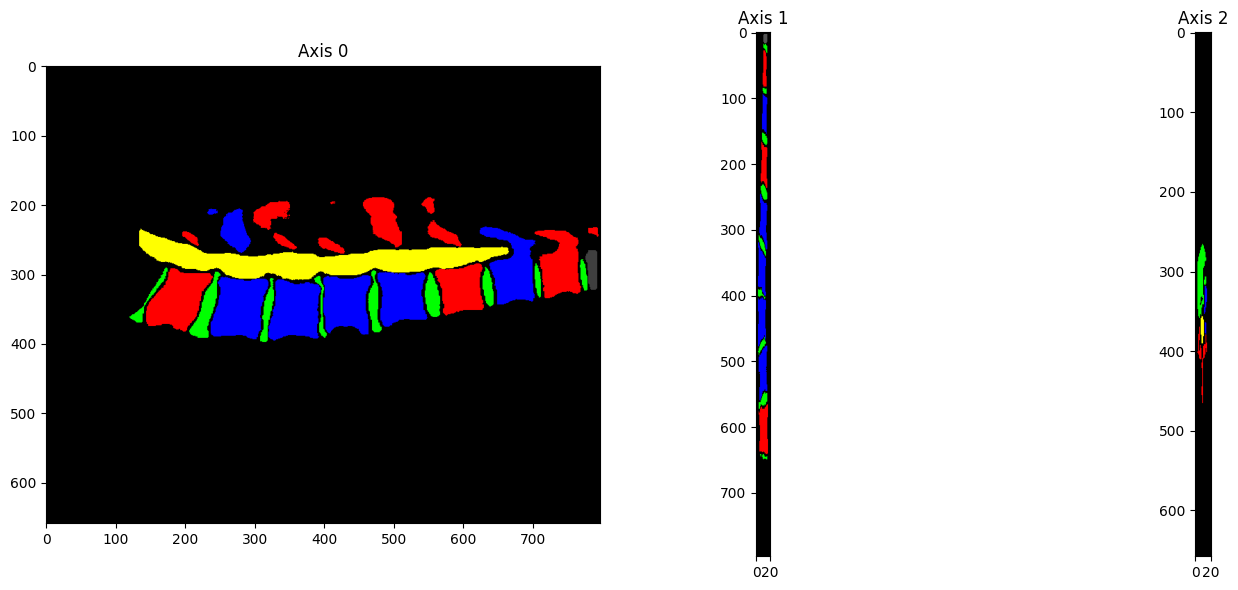

In [15]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import label, binary_erosion, binary_closing, distance_transform_edt
from skimage.measure import regionprops
from skimage.segmentation import watershed
import os

# ==========================================
# CONFIGURATION
# ==========================================
INPUT_PATH  = "../odd-even-strategy/predictions/242_t2_pred.nii.gz"
INPUT_PATH = "../nnUNet_raw/Dataset501_SpiderOddEven/labelsTr/Spider_001.nii.gz"
OUTPUT_PATH = "../odd-even-strategy/predictions/242_t2_postprocessed.nii.gz"
SOLID_COLOR = True

# Tuning Parameters
MIN_BONE_VOLUME = 100    # Ignore fragments smaller than this (was 30)
MERGE_DISTANCE_THR = 15  # Merge cores closer than this (in voxels). ~10-15mm usually.

# ------------------------------------------------
# 1. UTILS
# ------------------------------------------------
def detect_spine_axis(blobs):
    if not blobs: return 0
    centroids = np.array([b['centroid'] for b in blobs])
    spreads = np.std(centroids, axis=0)
    spine_axis = np.argmax(spreads)
    print(f"   [Axis Detect] Spine detected along Axis {spine_axis} (Spread={spreads[spine_axis]:.1f})")
    return spine_axis

def merge_close_blobs(blobs, spine_axis, threshold=10):
    """
    If two blobs are too close along the spine axis, merge them.
    This fixes the 'sliced bread' effect where one bone is split in half.
    """
    if not blobs: return []
    
    # Sort by height
    blobs.sort(key=lambda x: x['centroid'][spine_axis])
    
    merged = []
    if not blobs: return merged
    
    current = blobs[0]
    
    for next_blob in blobs[1:]:
        dist = next_blob['centroid'][spine_axis] - current['centroid'][spine_axis]
        
        if dist < threshold:
            # MERGE
            # Combine bbox
            b1 = current['bbox']
            b2 = next_blob['bbox']
            
            # Simple bbox union
            new_bbox = (
                min(b1[0], b2[0]), min(b1[1], b2[1]), min(b1[2], b2[2]),
                max(b1[3], b2[3]), max(b1[4], b2[4]), max(b1[5], b2[5])
            )
            
            # Update current (we conceptually merge them)
            # Note: We don't update the mask here as it's complex, 
            # we just keep the 'current' label ID and discard the 'next' ID
            # effectively treating them as one unit for the zipper logic.
            # (The watershed will fill the space anyway)
            print(f"      -> Merging fragments at {current['centroid'][spine_axis]:.1f} and {next_blob['centroid'][spine_axis]:.1f} (dist={dist:.1f})")
            
            # We keep the 'current' valid, ignore 'next'
            # (In a real merge we'd average centroids, but keeping top one is fine for sorting)
            continue 
        else:
            merged.append(current)
            current = next_blob
            
    merged.append(current)
    return merged

# ------------------------------------------------
# 2. CORE EXTRACTION (HEAL -> ERODE -> FILTER)
# ------------------------------------------------
def get_healed_cores(lbl_data):
    binary_bone = (lbl_data == 1) | (lbl_data == 2)

    # A. CLOSING: Heal cracks inside the bones
    # iterations=2 fills gaps of ~4 pixels.
    print("   [1] Closing cracks...")
    closed_mask = binary_closing(binary_bone, iterations=2)
    
    # B. EROSION: Separate the vertebrae
    # Now that cracks are healed, erosion will only attack the Discs (bridges)
    print("   [2] Eroding connections...")
    eroded_mask = binary_erosion(closed_mask, iterations=1) 
    
    # C. LABEL & FILTER
    cc_cores, num_cores = label(eroded_mask)
    props = regionprops(cc_cores)
    
    valid_blobs = []
    for p in props:
        if p.area < MIN_BONE_VOLUME: continue 
        valid_blobs.append({
            "label_id": p.label,
            "centroid": p.centroid,
            "bbox": p.bbox
        })
        
    print(f"   [3] Found {len(valid_blobs)} potential cores (filtered from {num_cores}).")
    return valid_blobs, binary_bone, cc_cores

# ------------------------------------------------
# 3. RECONSTRUCTION
# ------------------------------------------------
def process_pipeline(lbl):
    # 1. Get Cores
    blobs, full_mask, core_labels = get_healed_cores(lbl)
    
    # 2. Detect Axis
    spine_axis = detect_spine_axis(blobs)
    
    # 3. SAFETY MERGE (The Fix for 19 -> 7)
    # If fragments are closer than 15 voxels, they are the same bone.
    print(f"   [4] Merging close fragments (Threshold={MERGE_DISTANCE_THR})...")
    final_blobs = merge_close_blobs(blobs, spine_axis, threshold=MERGE_DISTANCE_THR)
    print(f"       -> Final Count: {len(final_blobs)} vertebrae.")

    # 4. ZIPPER LOGIC
    # Sort
    final_blobs.sort(key=lambda x: x['centroid'][spine_axis])
    
    # Determine First Class
    if final_blobs:
        top_blob_mask = (core_labels == final_blobs[0]['label_id'])
        vals, counts = np.unique(lbl[top_blob_mask], return_counts=True)
        vote = dict(zip(vals, counts))
        current_class = 2 if vote.get(2, 0) > vote.get(1, 0) else 1
    else:
        current_class = 1

    # Prepare Markers for Watershed
    markers = np.zeros_like(core_labels, dtype=np.int32)
    blob_classes = {}
    
    for i, blob in enumerate(final_blobs, start=1):
        # We mark the core with the new ID
        markers[core_labels == blob['label_id']] = i
        blob_classes[i] = current_class
        current_class = 2 if current_class == 1 else 1
        
    # 5. WATERSHED FILL
    print("   [5] Watershed Expansion...")
    dist = distance_transform_edt(full_mask)
    final_inst = watershed(-dist, markers, mask=full_mask)
    
    # 6. ASSIGN CLASSES
    final_oe = np.zeros_like(final_inst, dtype=np.uint8)
    for inst_id, cls in blob_classes.items():
        final_oe[final_inst == inst_id] = cls
        
    # Restore Disc/Canal
    final_inst[lbl == 3] = 200
    final_inst[lbl == 4] = 255
    final_oe[lbl == 3] = 3
    final_oe[lbl == 4] = 4
    
    return final_inst, final_oe

# ------------------------------------------------
# VIEW & SAVE
# ------------------------------------------------
def visualize(img, inst, oe):
    z, y, x = img.shape
    mid = [z//2, y//2, x//2]
    fig, axs = plt.subplots(1, 3, figsize=(15, 6))
    
    def get_rgb(sl_img, sl_inst, sl_oe):
        sl_img = (sl_img - sl_img.min())/(sl_img.max() - sl_img.min() + 1e-5)
        rgb = np.stack([sl_img]*3, axis=-1)
        ids = np.unique(sl_inst)
        for i in ids:
            if i == 0: continue
            mask = (sl_inst == i)
            if i == 200: col = [0,1,0]
            elif i == 255: col = [1,1,0]
            else:
                c = sl_oe[mask][0]
                if c==1: col=[1,0,0]
                elif c==2: col=[0,0,1]
                else: col=[1,1,1]
            if SOLID_COLOR: rgb[mask] = col
            else: rgb[mask] = rgb[mask]*0.5 + np.array(col)*0.5
        return rgb

    axs[0].imshow(get_rgb(img[mid[0]], inst[mid[0]], oe[mid[0]]))
    axs[0].set_title("Axis 0")
    axs[1].imshow(np.rot90(get_rgb(img[:, mid[1], :], inst[:, mid[1], :], oe[:, mid[1], :])))
    axs[1].set_title("Axis 1")
    axs[2].imshow(np.rot90(get_rgb(img[:, :, mid[2]], inst[:, :, mid[2]], oe[:, :, mid[2]])))
    axs[2].set_title("Axis 2")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    if os.path.exists(INPUT_PATH):
        nii = nib.load(INPUT_PATH)
        lbl = nii.get_fdata().astype(np.uint8)
        img = lbl.astype(np.float32)
        
        final_inst, final_oe = process_pipeline(lbl)
        
        nib.save(nib.Nifti1Image(final_inst, nii.affine, nii.header), OUTPUT_PATH)
        print(f"   [Saved] {OUTPUT_PATH}")
        visualize(img, final_inst, final_oe)


Case 1
Shape: (144, 480, 160)
Labels: [0 1 2]
   > Found 10 Odd Vertebra blobs
   > Found 24 Even Vertebra blobs


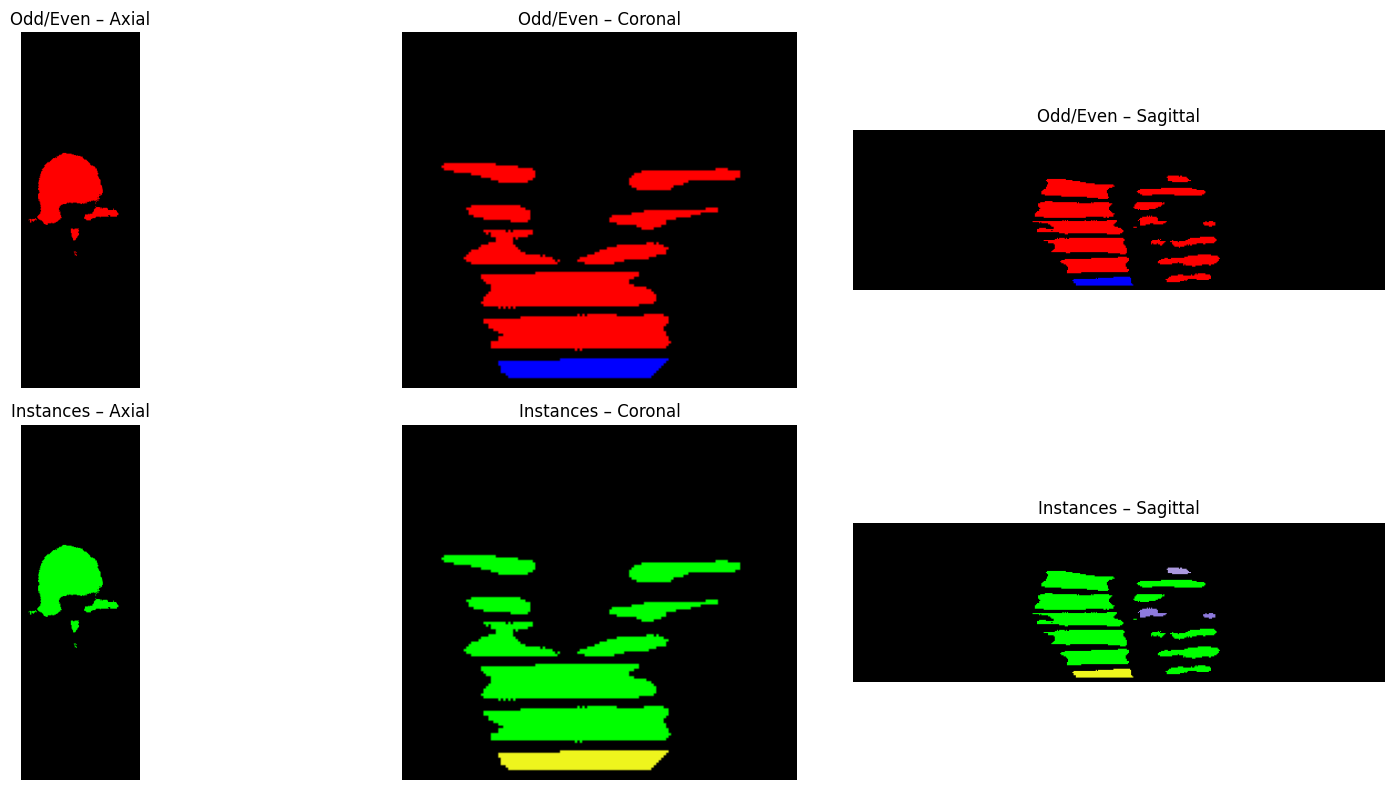

In [52]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label, center_of_mass
from matplotlib.colors import ListedColormap
import random

# -----------------------------
# INSTANCE LOGIC (YOUR METHOD)
# -----------------------------
def get_blobs_info(binary_mask, class_name):
    labeled_vol, num = label(binary_mask, structure=np.ones((3,3,3)))
    print(f"   > Found {num} {class_name} blobs")

    if num == 0:
        return []

    centroids = center_of_mass(binary_mask, labeled_vol, range(1, num + 1))

    blobs = []
    for i, cent in enumerate(centroids):
        blobs.append({
            "z": cent[2],                 # Z-axis height
            "mask": labeled_vol == (i+1),
            "type": class_name
        })
    return blobs


def vertebra_instance_labeling(lbl):
    """
    Instance labeling using ODD/EVEN separation (correct logic)
    """
    inst = np.zeros_like(lbl, dtype=np.uint16)

    # Separate odd & even (they never touch)
    blobs_odd  = get_blobs_info(lbl == 1, "Odd Vertebra")
    blobs_even = get_blobs_info(lbl == 2, "Even Vertebra")

    all_blobs = blobs_odd + blobs_even

    # Sort head → feet (reverse if needed)
    all_blobs.sort(key=lambda x: x["z"], reverse=True)

    print("   > Total vertebrae:", len(all_blobs))

    current_id = 1
    for blob in all_blobs:
        inst[blob["mask"]] = current_id
        current_id += 1

    return inst

def vertebra_instance_labeling_with_semantics(lbl):
    inst = np.zeros_like(lbl, dtype=np.uint16)

    blobs_odd  = get_blobs_info(lbl == 1, "Odd Vertebra")
    blobs_even = get_blobs_info(lbl == 2, "Even Vertebra")

    all_blobs = blobs_odd + blobs_even
    all_blobs.sort(key=lambda x: x["z"], reverse=True)

    current_id = 1
    for blob in all_blobs:
        inst[blob["mask"]] = current_id
        current_id += 1

    # ---- ADD SEMANTIC OVERLAYS ----
    inst[lbl == 3] = 200   # Discs
    inst[lbl == 4] = 255   # Canal

    return inst



# -----------------------------
# VISUALIZATION
# -----------------------------
def displayLabels(case_id=1):
    LABEL_PATH = "../odd-even-strategy/predictions/242_t2_pred.nii.gz"

    nii = nib.load(LABEL_PATH)
    lbl = nii.get_fdata().astype(np.uint8)

    lbl = odd_even_map

    print(f"\nCase {case_id}")
    print("Shape:", lbl.shape)
    print("Labels:", np.unique(lbl))

    inst_lbl = vertebra_instance_labeling_with_semantics(lbl)

    # Center slices
    z = lbl.shape[0] // 2
    y = lbl.shape[1] // 2
    x = lbl.shape[2] // 2

    # ---- Colormaps ----
    five_class_cmap = ListedColormap([
        "black",   # 0 background
        "red",     # 1 odd
        "blue",    # 2 even
        "yellow",  # 3 disc
        "green"    # 4 canal
    ])

    # Random instance colors
    n_inst = inst_lbl.max()
    colors = [(0,0,0)] + [
        (random.random(), random.random(), random.random())
        for _ in range(n_inst)
    ]

    colors.append((1.0, 1.0, 0.0))  # 200 → Disc (Yellow)
    colors.append((0.0, 1.0, 0.0))  # 255 → Canal (Green)

    inst_cmap = ListedColormap(colors)

    # ---- Plot ----
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    # Row 1 – Odd/Even mask
    axes[0,0].imshow(lbl[z,:,:], cmap=five_class_cmap, vmin=0, vmax=4)
    axes[0,0].set_title("Odd/Even – Axial")

    axes[0,1].imshow(lbl[:,y,:], cmap=five_class_cmap, vmin=0, vmax=4)
    axes[0,1].set_title("Odd/Even – Coronal")

    axes[0,2].imshow(lbl[:,:,x], cmap=five_class_cmap, vmin=0, vmax=4)
    axes[0,2].set_title("Odd/Even – Sagittal")

    # Row 2 – Instance labels
    axes[1,0].imshow(inst_lbl[z,:,:], cmap=inst_cmap)
    axes[1,0].set_title("Instances – Axial")

    axes[1,1].imshow(inst_lbl[:,y,:], cmap=inst_cmap)
    axes[1,1].set_title("Instances – Coronal")

    axes[1,2].imshow(inst_lbl[:,:,x], cmap=inst_cmap)
    axes[1,2].set_title("Instances – Sagittal")

    for ax in axes.flatten():
        ax.axis("off")

    plt.tight_layout()
    plt.show()

displayLabels()

### Updated U-Net model for odd-even 5 class segmentation

In [ ]:
import torch
import torch.nn as nn
from monai.networks.nets import UNet
from monai.networks.blocks import Convolution

class UNetOddEvenWithPosition(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        # ---- SHARED ENCODER + DECODER ----
        self.unet = UNet(
            spatial_dims=3,
            in_channels=1,
            out_channels=64,     # shared feature map
            channels=(32, 64, 128, 256),
            strides=(1, 2, 2),   # IMPORTANT FIX (no early Z downsampling)
            num_res_units=2,
        )

        # ---- MAIN HEAD (ODD / EVEN / ETC) ----
        self.seg_head = Convolution(
            spatial_dims=3,
            in_channels=64,
            out_channels=num_classes,
            kernel_size=1,
            act=None,
            norm=None
        )

        # ---- AUX POSITION HEAD (REGRESSION) ----
        self.pos_head = Convolution(
            spatial_dims=3,
            in_channels=64,
            out_channels=1,     # relative Z position
            kernel_size=1,
            act=None,
            norm=None
        )

    def forward(self, x):
        features = self.unet(x)

        seg_logits = self.seg_head(features)      # (B, C, Z, Y, X)
        pos_logits = self.pos_head(features)      # (B, 1, Z, Y, X)

        return seg_logits, pos_logits


In [11]:
model = UNetOddEvenWithPosition(
    num_classes=5
).to(device)


from monai.losses import DiceCELoss

ce_weights = torch.tensor(
    [1.0, 2.0, 2.0, 1.5, 1.5],
    device=device
)

loss_fn = DiceCELoss(
    include_background=False,
    softmax=True,
    to_onehot_y=True,
    lambda_dice=0.7,
    lambda_ce=0.3,
    ce_weight=ce_weights
)

import torch
import torch.nn.functional as F

def extract_boundary(mask, kernel_size=3):
    """
    mask: (B, C, Z, Y, X) one-hot GT
    returns: boundary mask same shape
    """
    padding = kernel_size // 2
    pooled = F.max_pool3d(
        mask.float(),
        kernel_size=kernel_size,
        stride=1,
        padding=padding
    )
    boundary = pooled - mask
    return boundary.clamp(0, 1)

def boundary_dice_loss(logits, gt):
    """
    logits: (B, C, Z, Y, X)
    gt:     (B, Z, Y, X)
    """
    gt_oh = torch.nn.functional.one_hot(
        gt, num_classes=logits.shape[1]
    ).permute(0,4,1,2,3)

    boundary = extract_boundary(gt_oh)

    probs = torch.softmax(logits, dim=1)
    return dice(probs * boundary, gt_oh * boundary)


BOUNDARY_WEIGHT = 0.15  # DO NOT exceed 0.2

def total_loss(logits, gt):
    return (
        loss_fn(logits, gt)
        + BOUNDARY_WEIGHT * boundary_dice_loss(logits, gt)
    )

In [12]:
# =============================
# Cell 9: Training loop
# =============================
n_epochs = 30
best_val_dice = 0.0
ROI_SIZE   = (128, 96, 96)   # patch size, divisible by 16
OVERLAP    = 0.25
save_path = os.path.join(OUTPUT_DIR, "best_model8.pth")

for epoch in range(1, n_epochs+1):
    model.train()
    train_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{n_epochs} train"):
        images, masks = batch['image'].to(device), batch['mask'].long().to(device)
        images, masks = pad_to_multiple_pair(images, masks)
        
        optimizer.zero_grad()
        with torch.amp.autocast(device_type="cuda"):
            outputs = model(images)
            # loss = combined_loss(outputs, masks)
            masks = masks.unsqueeze(1)   # [B, 1, Z, Y, X]
            loss = total_loss(outputs, masks)  # labels: (B,Z,Y,X)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss, dices = 0.0, []
    with torch.no_grad():
        for batch in val_loader:
            images, masks = batch['image'].to(device), batch['mask'].long().to(device)
            images, masks = pad_to_multiple_pair(images, masks)
            outputs = model(images)
            # vloss = combined_loss(outputs, masks).item()
            masks = masks.unsqueeze(1)   # [B, 1, Z, Y, X]
            vloss = total_loss(outputs, masks)  # labels: (B,Z,Y,X)
            val_loss += vloss.item()

            probs = torch.softmax(outputs, dim=1)
            pred  = torch.argmax(probs, dim=1)  # (B,Z,Y,X)

            per_class_d = []
            for cls in range(1, 5):
                inter = ((pred == cls) & (masks == cls)).sum()
                union = (pred == cls).sum() + (masks == cls).sum()
                dice  = (2 * inter / union).item() if union > 0 else 1.0
                per_class_d.append(dice)
            dices.append(per_class_d)

            # probs = torch.sigmoid(outputs)
            # pred = (probs > 0.5).float()

            # per_class_d = []
            # for c in range(num_classes):
            #     inter = (pred[:,c]*masks[:,c]).sum()
            #     union = pred[:,c].sum() + masks[:,c].sum()
            #     per_class_d.append((2*inter/union).item() if union>0 else 1.0)
            # dices.append(per_class_d)

    val_loss /= len(val_loader)
    mean_dice = np.mean(np.array(dices), axis=0)
    print(f"Epoch {epoch} train_loss {train_loss:.4f} val_loss {val_loss:.4f} Dice {mean_dice}")

    scheduler.step(val_loss)
    if mean_dice.mean() > best_val_dice:
        best_val_dice = mean_dice.mean()
        torch.save(model.state_dict(), save_path)
        print("Saved best model.")

print("Training finished. Best val dice:", best_val_dice)


Epoch 1/30 train:   0%|          | 0/120 [00:28<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 414.00 MiB. GPU 0 has a total capacity of 4.00 GiB of which 0 bytes is free. Of the allocated memory 6.03 GiB is allocated by PyTorch, and 710.22 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)